# Monte Carlo Simulations

In [10]:
import numpy as np
from scipy import stats
import plotly.express as px

rng = np.random.default_rng(123)

n = 1000

In [4]:
# t-student distribution
x = stats.t.rvs(df=3, size=n, random_state=rng)

# cauchy
x = stats.cauchy.rvs(size=n, random_state=rng)

# pareto
x = stats.pareto.rvs(b=3, size=n, random_state=rng)

# frechet
x = stats.invweibull.rvs(c=2, size=n, random_state=rng)

# lévy
x = stats.levy.rvs(size=n, random_state=rng)

# lévy-stable family
x = stats.levy_stable.rvs(alpha=1.5, beta=0, size=n, random_state=rng)

In [ ]:
import plotly.express as px

dists = []

In [ ]:
np.random.see

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

class HeavyTailSimulator:
    def __init__(self, n=1000, seed=42):
        self.n = n
        self.rng = np.random.default_rng(seed)
        
        # We "freeze" the distributions with their parameters here
        self.distributions = {
            "Student-t (df=3)": stats.t(df=3),
            "Cauchy":           stats.cauchy(),
            "Pareto (b=3)":     stats.pareto(b=3),
            "Frechet (c=2)":    stats.invweibull(c=2),
            "Lévy":             stats.levy(),
            "Lévy-Stable":      stats.levy_stable(alpha=1.5, beta=0)
        }

    def generate_all(self):
        """Generates a dictionary of raw samples."""
        return {
            name: dist.rvs(size=self.n, random_state=self.rng) 
            for name, dist in self.distributions.items()
        }

    def plot_comparison(self, x_range=(-5, 5)):
        """Plots the PDFs of all distributions together."""
        x = np.linspace(x_range[0], x_range[1], 1000)
        plt.figure(figsize=(10, 6))

        for name, dist in self.distributions.items():
            plt.plot(x, dist.pdf(x), label=name, lw=2)

        plt.title("Comparison of Heavy-Tailed Distributions")
        plt.xlabel("Value")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.ylim(0, 1) # Clipping for visibility
        plt.show()

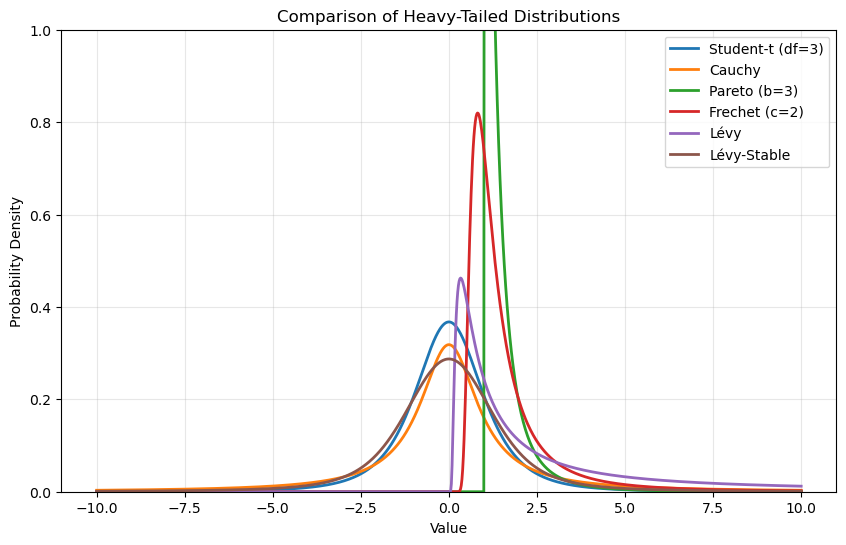

In [6]:
sim = HeavyTailSimulator(n=500)

# 1. Get raw data for your stationarity tests
samples = sim.generate_all() 
cauchy_data = samples["Cauchy"]

# 2. Visualize the shapes
sim.plot_comparison(x_range=(-10, 10))

In [8]:
import numpy as np

T = 200
K = 3
grid = np.linspace(0,1,200)

# Fourier basis
phi = [
    np.ones_like(grid),
    np.sqrt(2)*np.sin(2*np.pi*grid),
    np.sqrt(2)*np.cos(2*np.pi*grid)
]

xi = np.zeros((T,K))
rho = [0.9,0.6,0.3]

for t in range(1,T):
    xi[t] = rho*xi[t-1] + np.random.normal(size=K)

g = np.zeros((T,len(grid)))

for t in range(T):
    for k in range(K):
        g[t] += xi[t,k]*phi[k]

f = np.exp(g)
f = f / np.trapezoid(f,grid,axis=1)[:,None]

In [ ]:
import numpy as np
from scipy import stats
from typing import Optional, Dict, Callable

class HeavyTailSimulator:
    """
    A factory class for generating random variates from various light and 
    heavy-tailed distributions using a modern, encapsulated RNG.

    This class provides a centralized interface for simulating stochastic 
    processes common in Financial Mathematics and Extreme Value Theory (EVT).
    It ensures reproducibility by maintaining a local 'np.random.Generator' 
    instance, preventing state pollution across different simulation runs.

    Attributes
    -----------
        n (int): Default number of samples to generate per call.
        seed (int): The seed used to initialize the PCG64 random generator.
        rng (np.random.Generator): The encapsulated local random state.

    Example
    -----------
        >>> sim = HeavyTailSimulator(n=500, seed=42)
        >>> normal_data = sim.normal(loc=0, scale=1)
        >>> t_data = sim.student_t(df=3)

    """

    def __init__(self, n: int = 1000, seed: int = 42):
        self.n = n
        self.seed = seed
        self.rng = np.random.default_rng(seed)

    def normal(self, loc: float = 0, scale: float = 1, size: Optional[int] = None) -> np.ndarray:
        """Gaussian distribution (Benchmark for light tails)."""
        n = size if size else self.n
        return stats.norm.rvs(loc=loc, scale=scale, size=n, random_state=self.rng)

    def student_t(self, df: float = 3, loc: float = 0, scale: float = 1, size: Optional[int] = None) -> np.ndarray:
        """Student-t distribution (Fat-tailed; finite variance only if df > 2)."""
        n = size if size else self.n
        return stats.t.rvs(df=df, loc=loc, scale=scale, size=n, random_state=self.rng)

    def cauchy(self, loc: float = 0, scale: float = 1, size: Optional[int] = None) -> np.ndarray:
        """Cauchy distribution (Pathological; infinite mean and variance)."""
        n = size if size else self.n
        return stats.cauchy.rvs(loc=loc, scale=scale, size=n, random_state=self.rng)

    def pareto(self, b: float = 3, loc: float = 0, scale: float = 1, size: Optional[int] = None) -> np.ndarray:
        """Pareto Type II distribution (Power-law decay; used for extreme events)."""
        n = size if size else self.n
        return stats.pareto.rvs(b=b, loc=loc, scale=scale, size=n, random_state=self.rng)

    def frechet(self, c: float = 2, loc: float = 0, scale: float = 1, size: Optional[int] = None) -> np.ndarray:
        """Frechet (Inverse Weibull) distribution (Standard in Extreme Value Theory)."""
        n = size if size else self.n
        return stats.invweibull.rvs(c=c, loc=loc, scale=scale, size=n, random_state=self.rng)

    def levy(self, loc: float = 0, scale: float = 1, size: Optional[int] = None) -> np.ndarray:
        """Lévy distribution (Stable distribution with alpha=0.5, beta=1)."""
        n = size if size else self.n
        return stats.levy.rvs(loc=loc, scale=scale, size=n, random_state=self.rng)

    def levy_stable(self, alpha: float = 1.5, beta: float = 0, size: Optional[int] = None) -> np.ndarray:
        """General Lévy-Stable family (alpha controls the tail-index)."""
        n = size if size else self.n
        return stats.levy_stable.rvs(alpha=alpha, beta=beta, size=n, random_state=self.rng)

# --- Example Usage for Dissertation Simulations ---

if __name__ == "__main__":
    # Initialize simulator
    sim = HeavyTailSimulator(n=1000, seed=123)

    # Define a set of distributions to iterate over for a "Stress Test"
    # We use lambdas to pre-configure specific parameters for the iteration
    scenarios: Dict[str, Callable[[], np.ndarray]] = {
        "Standard Normal":   sim.normal,
        "Fat-Tailed (T,3)":  lambda: sim.student_t(df=3),
        "Extreme (Cauchy)":  sim.cauchy,
        "Pareto (b=1.5)":    lambda: sim.pareto(b=1.5),
        "Stable (α=1.7)":    lambda: sim.levy_stable(alpha=1.7)
    }

    print(f"{'Distribution':<20} | {'Mean':<10} | {'Max Value':<10}")
    print("-" * 45)

    for name, generator in scenarios.items():
        # Generate data
        data = generator()
        
        # Calculate statistics (Note: Mean might be nonsensical for Cauchy/Levy)
        avg = np.mean(data)
        peak = np.max(data)
        
        print(f"{name:<20} | {avg:<10.4f} | {peak:<10.4f}")